In [2]:
import os, json, random, time, math, re, shutil, inspect
from pathlib import Path
from typing import List, Dict

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
from torch.utils.data import Dataset as TorchDataset

from datasets import load_dataset
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import MolToSmiles

import matplotlib.pyplot as plt

from transformers import (
    GPT2Config, GPT2LMHeadModel,
    Trainer, TrainingArguments,
    set_seed
)

print("Setup complete. Torch CUDA:", torch.cuda.is_available())


2025-10-16 13:09:14.973418: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /opt/sw/other/apps/cudnn/cudnn-linux-x86_64-9.6.0.74_cuda12-archive/lib:/opt/sw/other/apps/cuda/12.6.3/lib64:/opt/sw/spack/apps/linux-rhel8-x86_64_v2/gcc-10.3.0/openmpi-4.1.2-4a/lib:/opt/sw/spack/apps/linux-rhel8-x86_64_v2/gcc-10.3.0/python-3.9.9-jh/lib:/opt/sw/spack/apps/linux-rhel8-x86_64_v2/gcc-10.3.0/sqlite-3.37.1-6s/lib:/opt/sw/spack/apps/linux-rhel8-x86_64_v2/gcc-10.3.0/zlib-1.2.11-2y/lib:/opt/sw/spack/apps/linux-rhel8-x86_64_v2/gcc-9.3.0/gcc-10.3.0-ya/lib64:/opt/sw/spack/apps/linux-rhel8-x86_64_v2/gcc-9.3.0/gcc-10.3.0-ya/lib
2025-10-16 13:09:14.973451: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


Setup complete. Torch CUDA: True


In [4]:
# =========================
# Cell 1 — Config, Seeds, Paths
# =========================
SEED = 1337
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

RUN_DIR = Path("runs/m1_chem_tok_v1"); RUN_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "seed": SEED,
    "max_len_cap": 256,
    "ctx_len": 256,
    "model_dims": {"n_layer": 8, "n_head": 8, "n_embd": 512},

    # --- NEW: Birdie-style pretraining config ---
    "pretrain": {
        "enabled": True,
        "epochs": 1,                 # light pretrain; tune as needed
        "lr": 3e-4,
        "weight_decay": 0.05,
        "warmup_steps": 2000,
        "per_device_batch": 32,
        "grad_accum": 4,
        "fp16": True,
        "prefix_mask": {
            "min_ratio": 0.0,        # min fraction of sequence treated as prefix
            "max_ratio": 0.8,        # max fraction (labels = -100 for [0:k))
            "strategy": "uniform"    # ["uniform"]
        },
        "save_steps": 2500,
        "logging_steps": 200,
    },

    # --- Finetune (regular causal LM) ---
    "train": {
        "epochs": 5,
        "lr": 3e-4,
        "weight_decay": 0.05,
        "warmup_steps": 5000,
        "per_device_batch": 32,
        "grad_accum": 4,
        "fp16": True,
        "save_steps": 2000,
        "logging_steps": 200,
        "smiles_randomize_prob": 0.7
    },

    "sampling": {"n": 5000, "top_p": 0.95, "temperature": 1.0, "max_length": 128},

    "safety": {
        "skip_train_if_model_exists": True,  # if a final model exists, don't retrain
        "auto_resume_from_last_ckpt": True   # resume if checkpoints exist
    }
}
with open(RUN_DIR / "config.json", "w") as f: json.dump(CONFIG, f, indent=2)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Config saved ->", RUN_DIR / "config.json", "| Device:", DEVICE)




Config saved -> runs/m1_chem_tok_v1/config.json | Device: cuda


In [5]:
# ====== Cell A — Extend CONFIG for multi-task & RL ======
# Add once (safe to re-run)

CONFIG.setdefault("tasks", {
    "prefix":  {"on": True,  "p": 0.30},   # already implemented as PrefixLMDataset
    "suffix":  {"on": True,  "p": 0.15},   # new
    "span":    {"on": True,  "p": 0.25},   # new: random span infilling (AR)
    "frag":    {"on": True,  "p": 0.15},   # new: fragment completion (uses Murcko)
    "denoise": {"on": True,  "p": 0.15},   # new: corruption -> clean
})
CONFIG.setdefault("tasks_misc", {
    "span_max_span_len": 10,
    "span_min_spans": 1,
    "span_max_spans": 3,
    "beta_curriculum": {"on": False, "a0": 1.5, "b0": 5.0, "aT": 5.0, "bT": 1.5}
})
CONFIG.setdefault("rl", {
    "enabled": True,
    "method": "rsft",                 # ["rsft"] in this minimal version
    "rounds": 2,                      # number of RS-FT rounds
    "samples_per_round": 10000,       # how many molecules to sample per round
    "keep_top_pct": 0.2,              # keep top 20% by reward
    "lr": 1e-5,                       # small LR for RS-FT
    "epochs": 1,                      # 1-2 small epochs per RS-FT round
    "per_device_batch": 32,
    "grad_accum": 2,
    "fp16": True
})

with open(RUN_DIR / "config.json", "w") as f:
    json.dump(CONFIG, f, indent=2)
print("CONFIG updated with tasks + rl.")


CONFIG updated with tasks + rl.


In [12]:
# ===== Run this before Cell B if you restarted kernel =====
# Recreate tokenizer from saved file

import json
from pathlib import Path

RUN_DIR = Path("runs/m1_chem_tok_v1")  # change if your run dir differs
chem_tok_path = RUN_DIR / "chem_tokenizer.json"

with open(chem_tok_path) as f:
    chem_tok_info = json.load(f)

class ChemTokenizer:
    def __init__(self, info):
        self.itos = info["itos"]; self.stoi = info["stoi"]
        self.pad_token = info["pad_token"]; self.bos_token = info["bos_token"]
        self.eos_token = info["eos_token"]; self.unk_token = info["unk_token"]
        self.pad_token_id = self.stoi[self.pad_token]
        self.bos_token_id = self.stoi[self.bos_token]
        self.eos_token_id = self.stoi[self.eos_token]
        self.unk_token_id = self.stoi[self.unk_token]
        self.vocab_size = len(self.itos)
        self.max_length = int(info.get("max_length", 128))

    def encode(self, text):
        from rdkit import Chem
        toks = chem_tokenize(text)
        ids_mid = [self.stoi.get(t, self.unk_token_id) for t in toks][: self.max_length - 2]
        ids = [self.bos_token_id] + ids_mid + [self.eos_token_id]
        pad_len = self.max_length - len(ids)
        if pad_len > 0:
            ids += [self.pad_token_id]*pad_len
        attn = [1]*(len(ids)-pad_len) + [0]*pad_len
        return {"input_ids": ids, "attention_mask": attn}

ctok = ChemTokenizer(chem_tok_info)
print("ChemTokenizer reloaded | Vocab size:", ctok.vocab_size)


ChemTokenizer reloaded | Vocab size: 27


In [13]:
# ====== Cell B — New datasets for multi-Birdie =================================================
# Requirements in scope before running:
# - ctok (an instance of ChemTokenizer from your earlier cell)
# - chem_tokenize(smiles: str) -> List[str]
# - randomize_smiles(can_smi: str) -> str
# - CONFIG (already set)
# If you restarted the kernel, re-run your tokenizer cell first to define ctok & helpers.

import random
import numpy as np
import torch
from typing import List

from torch.utils.data import Dataset as TorchDataset
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import QED, AllChem, DataStructs

# --- Ensure ChemTokenizer name exists for type hints (no-op if already defined) ----------------
try:
    ChemTokenizer
except NameError:  # pragma: no cover
    class ChemTokenizer:  # minimal stub for typing; real class is defined in your tokenizer cell
        pass

# --- Utility: safe stoi -----------------------------------------------------------------------
def _stoi(tok: ChemTokenizer, t: str) -> int:
    return tok.stoi.get(t, tok.unk_token_id)

# =========================
# Suffix-LM: optimize prefix (mask loss on suffix)
# =========================
class SuffixLMDataset(TorchDataset):
    def __init__(self, df, tokenizer: ChemTokenizer, rand_prob: float,
                 min_ratio: float = 0.0, max_ratio: float = 0.8, strategy: str = "uniform"):
        self.df = df.reset_index(drop=True)
        self.tok = tokenizer
        self.rand_prob = rand_prob
        self.min_ratio = float(min_ratio)
        self.max_ratio = float(max_ratio)
        self.strategy = strategy

    def __len__(self): return len(self.df)

    def _pick_cut(self, effective_len: int) -> int:
        if effective_len <= 2: 
            return max(1, effective_len - 1)
        if self.strategy == "uniform":
            r = random.random() * (self.max_ratio - self.min_ratio) + self.min_ratio
        else:
            r = random.random() * (self.max_ratio - self.min_ratio) + self.min_ratio
        return int(max(1, min(effective_len - 1, round(r * effective_len))))

    def __getitem__(self, idx):
        s = self.df.iloc[idx]["smiles"]
        if random.random() < self.rand_prob:
            s = randomize_smiles(s)
        enc = self.tok.encode(s)
        input_ids = torch.tensor(enc["input_ids"], dtype=torch.long)
        attention_mask = torch.tensor(enc["attention_mask"], dtype=torch.long)

        labels = input_ids.clone()
        labels[labels == self.tok.pad_token_id] = -100

        eff_len = int(attention_mask.sum().item())
        k = self._pick_cut(eff_len)
        labels[k:] = -100  # mask loss on suffix
        return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}

# =========================
# Span-Infilling (AR): insert <gap*> sentinels; target is concatenated missing spans
# =========================
GAP_TOKS = [f"<gap{i}>" for i in range(1, 6)]
SEP_TOK  = "<sep>"

# Extend tokenizer in-memory with sentinels if not present
added = 0
for special in GAP_TOKS + [SEP_TOK]:
    if special not in ctok.stoi:
        ctok.stoi[special] = len(ctok.itos)
        ctok.itos.append(special)
        added += 1
if added:
    ctok.vocab_size = len(ctok.itos)
    # Note: this is an in-memory extension; persist to disk if you want it saved.
    print(f"[info] Extended vocab with {added} sentinel tokens. New size = {ctok.vocab_size}")

class SpanInfillingDataset(TorchDataset):
    def __init__(self, df, tok: ChemTokenizer, rand_prob=0.7,
                 n_spans=(1,3), max_span_len=10):
        self.df = df.reset_index(drop=True)
        self.tok = tok
        self.rand_prob = rand_prob
        self.n_spans = n_spans
        self.max_span_len = max_span_len

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        s = self.df.iloc[idx]["smiles"]
        if random.random() < self.rand_prob:
            s = randomize_smiles(s)
        toks = chem_tokenize(s)
        L = len(toks)
        if L < 4:
            # fallback to standard LM when too short
            enc = self.tok.encode(s)
            input_ids = torch.tensor(enc["input_ids"], dtype=torch.long)
            attention_mask = torch.tensor(enc["attention_mask"], dtype=torch.long)
            labels = input_ids.clone(); labels[labels == self.tok.pad_token_id] = -100
            return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}

        k = random.randint(self.n_spans[0], self.n_spans[1])
        spans = []
        for _ in range(k):
            a = random.randint(1, max(1, L - 2))
            span_len = random.randint(1, min(self.max_span_len, max(1, int(0.15 * L))))
            b = min(L, a + span_len)
            # simple non-overlap retry
            tries = 0
            while any(a < x2 and b > x1 for (x1, x2) in spans) and tries < 6:
                a = random.randint(1, max(1, L - 2))
                span_len = random.randint(1, min(self.max_span_len, max(1, int(0.15 * L))))
                b = min(L, a + span_len)
                tries += 1
            spans.append((a, b))
        spans = sorted(spans)

        inp, targets = [], []
        cur = 0
        for gid, (a, b) in enumerate(spans, start=1):
            inp += toks[cur:a] + [f"<gap{gid}>"]
            targets += toks[a:b] + [SEP_TOK]
            cur = b
        inp += toks[cur:]

        in_ids  = [ctok.bos_token_id] + [_stoi(ctok, t) for t in inp]
        tgt_ids = [_stoi(ctok, t) for t in targets] + [ctok.eos_token_id]
        ids = (in_ids + tgt_ids)[: ctok.max_length]
        attn = [1] * len(ids)
        pad = ctok.max_length - len(ids)
        if pad > 0:
            ids  += [ctok.pad_token_id] * pad
            attn += [0] * pad

        labels = torch.tensor(ids, dtype=torch.long)
        split = len(in_ids)  # only train on target tail
        labels[:split] = -100
        return {
            "input_ids": torch.tensor(ids, dtype=torch.long),
            "attention_mask": torch.tensor(attn, dtype=torch.long),
            "labels": labels
        }

# =========================
# Fragment (Murcko) completion: "<bos> FRAG <sep> FULL <eos>", mask loss on fragment+sep
# =========================
def murcko_fragment(smi: str) -> str:
    m = Chem.MolFromSmiles(smi)
    if m is None: return ""
    core = MurckoScaffold.GetScaffoldForMol(m)
    return Chem.MolToSmiles(core, isomericSmiles=True, canonical=True)

class FragmentCompletionDataset(TorchDataset):
    def __init__(self, df, tok: ChemTokenizer, rand_prob=0.7):
        self.df = df.reset_index(drop=True)
        self.tok = tok
        self.rand_prob = rand_prob

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        s_full = self.df.iloc[idx]["smiles"]
        s_frag = murcko_fragment(s_full)
        if random.random() < self.rand_prob:
            s_full = randomize_smiles(s_full)

        frag_toks = chem_tokenize(s_frag) if s_frag else []
        full_toks = chem_tokenize(s_full)
        inp_toks  = frag_toks + [SEP_TOK] + full_toks

        ids = [ctok.bos_token_id] + [_stoi(ctok, t) for t in inp_toks] + [ctok.eos_token_id]
        ids = ids[: ctok.max_length]
        attn = [1] * len(ids)
        pad = ctok.max_length - len(ids)
        if pad > 0:
            ids  += [ctok.pad_token_id] * pad
            attn += [0] * pad

        labels = torch.tensor(ids, dtype=torch.long)
        mask_len = 1 + len(frag_toks) + 1  # <bos> + fragment + <sep>
        labels[:mask_len] = -100  # only train on completion part
        return {
            "input_ids": torch.tensor(ids, dtype=torch.long),
            "attention_mask": torch.tensor(attn, dtype=torch.long),
            "labels": labels
        }

# =========================
# Denoising: light chem-aware noise -> reconstruct clean canonical
# =========================
def small_noisify(s: str) -> str:
    # conservative: 50% randomized SMILES; else a tiny bond toggle where possible
    if random.random() < 0.5:
        return randomize_smiles(s)
    if "-" in s and random.random() < 0.5:
        return s.replace("-", "=", 1)
    if "=" in s:
        return s.replace("=", "-", 1)
    return s

class DenoiseDataset(TorchDataset):
    def __init__(self, df, tok: ChemTokenizer, rand_prob=1.0):
        self.df = df.reset_index(drop=True)
        self.tok = tok
        self.rand_prob = rand_prob

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        clean = self.df.iloc[idx]["smiles"]
        noisy = small_noisify(clean) if random.random() < self.rand_prob else clean

        noisy_toks = chem_tokenize(noisy)
        clean_toks = chem_tokenize(clean)

        ids = [ctok.bos_token_id] \
              + [_stoi(ctok, t) for t in noisy_toks] \
              + [_stoi(ctok, SEP_TOK)] \
              + [_stoi(ctok, t) for t in clean_toks] \
              + [ctok.eos_token_id]
        ids = ids[: ctok.max_length]
        attn = [1] * len(ids)
        pad = ctok.max_length - len(ids)
        if pad > 0:
            ids  += [ctok.pad_token_id] * pad
            attn += [0] * pad

        labels = torch.tensor(ids, dtype=torch.long)
        # mask "<bos> noisy <sep>"
        labels[: (1 + len(noisy_toks) + 1)] = -100
        return {
            "input_ids": torch.tensor(ids, dtype=torch.long),
            "attention_mask": torch.tensor(attn, dtype=torch.long),
            "labels": labels
        }

print("Cell B ready: SuffixLMDataset, SpanInfillingDataset, FragmentCompletionDataset, DenoiseDataset defined.")


[info] Extended vocab with 6 sentinel tokens. New size = 33
Cell B ready: SuffixLMDataset, SpanInfillingDataset, FragmentCompletionDataset, DenoiseDataset defined.


In [14]:
# ====== Cell C — Task mixer (IterableDataset) ==================================================
class TaskMixerIterable(IterableDataset):
    """
    Mix multiple supervised tasks by probability. Each underlying dataset is indexed
    randomly on-the-fly to provide an infinite stream for Trainer.
    """
    def __init__(self, datasets_with_p, batch_size=CONFIG["train"]["per_device_batch"]):
        super().__init__()
        self.datasets = [d for d,_ in datasets_with_p]
        self.probs     = np.array([p for _,p in datasets_with_p], dtype=np.float64)
        self.probs     = self.probs / self.probs.sum()
        self.batch_size = batch_size
        self.lengths = [len(d) for d in self.datasets]

    def __iter__(self):
        rng = np.random.default_rng(int(time.time()) % 2**32)
        while True:
            # pick a dataset
            k = rng.choice(len(self.datasets), p=self.probs)
            ds = self.datasets[k]
            # sample a random example
            idx = rng.integers(0, len(ds))
            yield ds[idx]

def build_multitask_dataset():
    tasks_cfg = CONFIG["tasks"]
    ds_with_p = []

    if tasks_cfg["prefix"]["on"]:
        ds_with_p.append((PrefixLMDataset(
            df_trn, ctok,
            rand_prob=CONFIG['train']['smiles_randomize_prob'],
            min_ratio=CONFIG['pretrain']['prefix_mask']['min_ratio'],
            max_ratio=CONFIG['pretrain']['prefix_mask']['max_ratio'],
            strategy=CONFIG['pretrain']['prefix_mask']['strategy']
        ), tasks_cfg["prefix"]["p"]))

    if tasks_cfg["suffix"]["on"]:
        ds_with_p.append((SuffixLMDataset(
            df_trn, ctok,
            rand_prob=CONFIG['train']['smiles_randomize_prob'],
            min_ratio=CONFIG['pretrain']['prefix_mask']['min_ratio'],
            max_ratio=CONFIG['pretrain']['prefix_mask']['max_ratio'],
            strategy=CONFIG['pretrain']['prefix_mask']['strategy']
        ), tasks_cfg["suffix"]["p"]))

    if tasks_cfg["span"]["on"]:
        ds_with_p.append((SpanInfillingDataset(
            df_trn, ctok,
            rand_prob=CONFIG['train']['smiles_randomize_prob'],
            n_spans=(CONFIG["tasks_misc"]["span_min_spans"], CONFIG["tasks_misc"]["span_max_spans"]),
            max_span_len=CONFIG["tasks_misc"]["span_max_span_len"]
        ), tasks_cfg["span"]["p"]))

    if tasks_cfg["frag"]["on"]:
        ds_with_p.append((FragmentCompletionDataset(
            df_trn, ctok, rand_prob=CONFIG['train']['smiles_randomize_prob']
        ), tasks_cfg["frag"]["p"]))

    if tasks_cfg["denoise"]["on"]:
        ds_with_p.append((DenoiseDataset(
            df_trn, ctok, rand_prob=1.0
        ), tasks_cfg["denoise"]["p"]))

    assert ds_with_p, "No tasks enabled."
    return TaskMixerIterable(ds_with_p)


In [16]:
# --- Patch: define build_fresh_model() if missing (drop this right before Cell D) ---

import torch
from transformers import GPT2Config, GPT2LMHeadModel

# Device fallback
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Safe matmul/TF32 tweaks (no-op on CPU)
try:
    torch.backends.cuda.matmul.allow_tf32 = True
except Exception:
    pass
try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

def _check_tok(tok):
    req = ["vocab_size", "max_length", "bos_token_id", "eos_token_id"]
    missing = [r for r in req if not hasattr(tok, r)]
    if missing:
        raise RuntimeError(f"ChemTokenizer is missing attributes: {missing}. "
                           f"Make sure you ran the tokenizer build cell.")

# Define only if not already present
if 'build_fresh_model' not in globals():
    def build_fresh_model():
        # Requires ctok and CONFIG in scope
        global ctok, CONFIG
        _check_tok(ctok)
        cfg = GPT2Config(
            vocab_size = ctok.vocab_size,
            n_positions = ctok.max_length,
            n_ctx = ctok.max_length,
            n_embd = CONFIG["model_dims"]["n_embd"],
            n_layer = CONFIG["model_dims"]["n_layer"],
            n_head = CONFIG["model_dims"]["n_head"],
            bos_token_id = ctok.bos_token_id,
            eos_token_id = ctok.eos_token_id,
            attn_implementation = "sdpa" if torch.__version__.startswith("2") else "eager",
        )
        m = GPT2LMHeadModel(cfg).to(DEVICE)
        # Tie weights & init embeddings
        with torch.no_grad():
            if hasattr(m.transformer, "wte"):
                m.transformer.wte.weight.normal_(mean=0.0, std=0.02)
                m.lm_head.weight = m.transformer.wte.weight
        return m

print("[patch] build_fresh_model() is now defined and ready.")


[patch] build_fresh_model() is now defined and ready.


In [18]:
# ====== Cell E — Reward functions for RS-FT (self-contained, safe to re-run) ===================
from pathlib import Path
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import QED
from rdkit.Chem import AllChem, DataStructs

# --- Ensure train_df is available (load cached clean set) --------------------------------------
if "RUN_DIR" not in globals():
    RUN_DIR = Path("runs/m1_chem_tok_v1")
else:
    RUN_DIR = Path(RUN_DIR)

clean_path = RUN_DIR / "train_clean.parquet"
if "train_df" not in globals():
    if clean_path.exists():
        train_df = pd.read_parquet(clean_path)
        print(f"[info] Loaded train_df from {clean_path} | n = {len(train_df):,}")
    else:
        raise FileNotFoundError(
            f"Couldn't find {clean_path}. Re-run your data cleaning cell to create it."
        )

# --- Canonicalization helper -------------------------------------------------------------------
def canonical_or_none(s: str):
    try:
        m = Chem.MolFromSmiles(s, sanitize=True)
        if m is None:
            return None
        return Chem.MolToSmiles(m, isomericSmiles=True, canonical=True)
    except Exception:
        return None

# --- Diversity helpers -------------------------------------------------------------------------
def _fp_bits(mol, n_bits=2048, radius=2):
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)

def _tanimoto(a, b):
    return DataStructs.TanimotoSimilarity(a, b)

class DiversityBuffer:
    def __init__(self, max_size=512):
        self.fps = []
        self.max_size = max_size

    def mean_dist(self, mol):
        if not self.fps:
            return 1.0
        try:
            fp = _fp_bits(mol)
        except Exception:
            return 0.0
        sims = [ _tanimoto(fp, f) for f in self.fps ]
        dists = [ 1.0 - s for s in sims ]
        return float(np.mean(dists)) if dists else 1.0

    def add(self, mols):
        for m in mols:
            try:
                fp = _fp_bits(m)
                self.fps.append(fp)
            except Exception:
                pass
        if len(self.fps) > self.max_size:
            self.fps = self.fps[-self.max_size:]

# Instantiate a global diversity buffer (used across RS-FT rounds)
div_buf = DiversityBuffer(max_size=512)

# --- Simple chemistry filter (same spirit as earlier approx_filter_ok) -------------------------
def approx_filter_ok(s):
    m = Chem.MolFromSmiles(s)
    if m is None:
        return False
    # keep only common organic atoms and neutral charge
    for a in m.GetAtoms():
        sym = a.GetSymbol()
        if sym not in {"C","N","O","S","F","Cl","Br"}:
            return False
        if a.GetFormalCharge() != 0:
            return False
    # ring-size sanity (reject very large rings)
    sssr = Chem.GetSymmSSSR(m)
    if any(len(r) > 8 for r in sssr):
        return False
    return True

# --- Precompute novelty reference --------------------------------------------------------------
train_set_canon = set(train_df["smiles"].tolist())

# --- Composite reward in [0,1] -----------------------------------------------------------------
def reward_smiles(s: str) -> float:
    """
    Reward = (valid & filter) * (0.45*QED + 0.25*diversity + 0.30*novelty), clipped to [0,1].
    """
    m = Chem.MolFromSmiles(s)
    if m is None:
        return 0.0

    # validity gate (by construction) + simple filter
    r_filt = 1.0 if approx_filter_ok(s) else 0.0
    if r_filt == 0.0:
        return 0.0

    # QED in [0,1]
    try:
        qed = float(QED.qed(m))
    except Exception:
        qed = 0.0

    # novelty vs training canon
    r_nov = 1.0 if s not in train_set_canon else 0.0

    # diversity vs replay buffer
    r_div = div_buf.mean_dist(m)  # ~[0,1]

    R = (0.45 * qed) + (0.25 * r_div) + (0.30 * r_nov)
    # gate by filter (validity already implied if RDKit parsed)
    R = r_filt * R
    return float(np.clip(R, 0.0, 1.0))

print("[ok] Reward functions ready: 'reward_smiles', 'div_buf', 'approx_filter_ok'.")


[info] Loaded train_df from runs/m1_chem_tok_v1/train_clean.parquet | n = 1,584,663
[ok] Reward functions ready: 'reward_smiles', 'div_buf', 'approx_filter_ok'.


In [27]:
# ====== Cell F (Fully Corrected for HF >= 4.43) — RS-FT loop ==============================
# Assumes: ctok, CONFIG, RUN_DIR, DEVICE, reward_smiles, canonical_or_none already exist.
import os, math, json, numpy as np, torch, re, time
from torch.utils.data import Dataset
from transformers import GPT2LMHeadModel, TrainingArguments, Trainer
from tqdm.auto import tqdm

# --- Quiet RDKit warnings (optional) ---
try:
    from rdkit import RDLogger, rdBase
    RDLogger.DisableLog('rdApp.*'); rdBase.DisableLog('rdApp.*')
except Exception:
    pass

# --- Restore chem_tokenize if missing (matches your earlier rules) ---
if 'chem_tokenize' not in globals():
    BRACKET_RE = re.compile(r"\[[^\[\]]+\]")
    RING2_RE   = re.compile(r"%\d{2}")
    TWO_LETTER = {"Cl","Br"}
    BONDS      = set(list("=#:-/\\."))     # keep '.'
    BRANCHES   = {"(",")"}
    DIGITS     = set(list("0123456789"))
    AROMATICS  = set(list("bcno sp".replace(" ","")))
    ELEMENTS   = set(list("BCNOPFISH"))

    def chem_tokenize(smiles: str):
        out = []
        i, L = 0, len(smiles or "")
        while i < L:
            ch = smiles[i]
            if ch == "[":
                m = BRACKET_RE.match(smiles, i)
                if m:
                    out.append(m.group(0)); i = m.end(); continue
            if ch == "%" and i+2 < L and smiles[i+1:i+3].isdigit():
                out.append(smiles[i:i+3]); i += 3; continue
            if i+1 < L and smiles[i:i+2] in TWO_LETTER:
                out.append(smiles[i:i+2]); i += 2; continue
            if ch in BRANCHES or ch in BONDS or ch in DIGITS or ch in AROMATICS or ch in ELEMENTS:
                out.append(ch); i += 1; continue
            out.append(ch); i += 1
        return out

# --- Collate expected by Trainer (token-wise stack) ---
def causal_collate(batch):
    keys = batch[0].keys()
    return {k: torch.stack([b[k] for b in batch]) for k in keys}

# --- Safe encode that doesn't rely on external globals beyond ctok + chem_tokenize ---
def encode_with_tok(tok, text: str):
    toks = chem_tokenize(text if isinstance(text, str) else "")
    ids_mid = [tok.stoi.get(t, tok.unk_token_id) for t in toks][: tok.max_length - 2]
    ids = [tok.bos_token_id] + ids_mid + [tok.eos_token_id]
    pad_len = tok.max_length - len(ids)
    if pad_len > 0:
        ids += [tok.pad_token_id] * pad_len
    attn = [1] * (len(ids) - max(0, pad_len)) + [0] * max(0, pad_len)
    return {"input_ids": ids, "attention_mask": attn}

# --- Ensure generation specials are set on the model ---
def _ensure_gen_config(m, tok):
    if getattr(m.config, "pad_token_id", None) is None or m.config.pad_token_id == getattr(m.config, "eos_token_id", None):
        m.config.pad_token_id = tok.pad_token_id
    if getattr(m.config, "bos_token_id", None) is None:
        m.config.bos_token_id = tok.bos_token_id
    if getattr(m.config, "eos_token_id", None) is None:
        m.config.eos_token_id = tok.eos_token_id

# --- Local decode (no dependency on ctok.decode) ---
_SPECIALS = None
def chem_decode_local(tok, ids, skip_special_tokens=True):
    global _SPECIALS
    if _SPECIALS is None:
        _SPECIALS = {tok.pad_token_id, tok.bos_token_id, tok.eos_token_id}
    out = []
    for i in ids:
        if skip_special_tokens and i in _SPECIALS: 
            continue
        if 0 <= i < tok.vocab_size:
            out.append(tok.itos[i])
    return "".join(out)

# --- Stable sampler with explicit attention_mask ---
def sample_molecules_batched(model, tok, n=5000, batch_size=64, top_p=0.95, temperature=1.0, req_max_len=128, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model.eval().to(device)
    _ensure_gen_config(model, tok)

    mconf = model.config
    bos_id = mconf.bos_token_id
    eos_id = mconf.eos_token_id
    pad_id = mconf.pad_token_id
    model_max_ctx = int(getattr(mconf, "n_positions", getattr(mconf, "n_ctx", tok.max_length)))
    max_len = min(int(req_max_len), model_max_ctx)

    out = []
    num_batches = math.ceil(n / batch_size)
    with torch.no_grad():
        for _ in tqdm(range(num_batches), desc="Sampling (RS-FT)"):
            bsz = min(batch_size, n - len(out))
            input_ids = torch.full((bsz, 1), bos_id, device=device, dtype=torch.long)
            attention_mask = torch.ones_like(input_ids, dtype=torch.long)
            gen = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_length=max_len,
                do_sample=True,
                top_p=top_p,
                temperature=temperature,
                pad_token_id=pad_id,
                eos_token_id=eos_id,
            ).tolist()
            out.extend(chem_decode_local(tok, seq, skip_special_tokens=True) for seq in gen)
    return out[:n]

# --- Weighted SFT dataset for RS-FT ---
class WeightedSFTDataset(Dataset):
    def __init__(self, smiles_list, weights, tok):
        self.smiles = smiles_list
        self.weights = weights
        self.tok = tok
    def __len__(self): return len(self.smiles)
    def __getitem__(self, idx):
        s = self.smiles[idx]
        enc = encode_with_tok(self.tok, s)
        input_ids = torch.tensor(enc["input_ids"], dtype=torch.long)
        attention_mask = torch.tensor(enc["attention_mask"], dtype=torch.long)
        labels = input_ids.clone(); labels[labels==self.tok.pad_token_id] = -100
        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
            "weights": torch.tensor(self.weights[idx], dtype=torch.float32)
        }

# --- Trainer that applies per-sample weights (normalized) ---
class WeightedCLSTrainer(Trainer):
    # NOTE: accept num_items_in_batch + **kwargs to be compatible with newer HF Trainer
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None, **kwargs):
        weights = inputs.pop("weights", None)
        outputs = model(**inputs)
        logits = outputs.logits
        labels = inputs["labels"]
        loss_fct = torch.nn.CrossEntropyLoss(reduction='none', ignore_index=-100)
        vocab_size = logits.size(-1)
        loss = loss_fct(logits.view(-1, vocab_size), labels.view(-1)).view(labels.size())
        token_mask = (labels != -100).float()
        per_sample = (loss * token_mask).sum(dim=1) / (token_mask.sum(dim=1) + 1e-8)
        if weights is not None:
            w = weights.to(per_sample.device).float()
            w = w / (w.mean() + 1e-8)
            loss_final = (per_sample * w).mean()
        else:
            loss_final = per_sample.mean()
        return (loss_final, outputs) if return_outputs else loss_final

# --- One RS-FT round: sample -> score -> keep top-p -> weighted SFT fine-tune ---
def rsft_round(policy_model, round_idx: int):
    print(f"\n=== RS-FT Round {round_idx+1}/{int(CONFIG['rl']['rounds'])} ===")
    _ensure_gen_config(policy_model, ctok)

    # 1) Sample
    n = int(CONFIG["rl"]["samples_per_round"])
    gen = sample_molecules_batched(
        policy_model, ctok,
        n=n, batch_size=64,
        top_p=CONFIG["sampling"]["top_p"],
        temperature=CONFIG["sampling"]["temperature"],
        req_max_len=CONFIG["sampling"]["max_length"],
        device=policy_model.device
    )

    # 2) Canonicalize & score (relies on canonical_or_none + reward_smiles)
    canons, rewards = [], []
    for g in gen:
        c = canonical_or_none(g)
        if c is None: 
            continue
        R = reward_smiles(c)
        canons.append(c); rewards.append(R)

    if not canons:
        print("[warn] No valid molecules in generation; skipping this round.")
        return policy_model

    # 3) Keep top-p%
    keep_p = float(CONFIG["rl"]["keep_top_pct"])
    k = max(1, int(len(canons) * keep_p))
    idxs = np.argsort(-np.array(rewards))[:k]
    kept = [canons[i] for i in idxs]
    kept_w = [float(rewards[i]) for i in idxs]
    print(f"Generated: {len(gen):,} | Valid: {len(canons):,} | Kept(top {int(keep_p*100)}%): {len(kept):,}")

    # 4) Weighted SFT fine-tune
    ds = WeightedSFTDataset(kept, kept_w, ctok)
    out_dir = RUN_DIR / f"rsft_round_{round_idx+1}"
    trainer = WeightedCLSTrainer(
        model=policy_model,
        args=TrainingArguments(
            output_dir=str(out_dir),
            learning_rate=float(CONFIG["rl"]["lr"]),
            weight_decay=0.0,
            warmup_steps=0,
            per_device_train_batch_size=int(CONFIG["rl"]["per_device_batch"]),
            gradient_accumulation_steps=int(CONFIG["rl"]["grad_accum"]),
            fp16=bool(CONFIG["rl"]["fp16"] and torch.cuda.is_available()),
            num_train_epochs=int(CONFIG["rl"]["epochs"]),
            report_to=[],
            save_strategy="no",
            logging_steps=100
        ),
        train_dataset=ds,
        data_collator=causal_collate
    )
    trainer.train()
    return policy_model

# --- Execute RS-FT rounds starting from your finetuned model and save the refined model ---
try:
    _start_dir = str(model_dir)  # from your finetune step
except NameError:
    _start_dir = str(RUN_DIR / "model_final")

print(f"[info] Using model from: {_start_dir}")
rs_policy = GPT2LMHeadModel.from_pretrained(_start_dir).to(DEVICE)
_ensure_gen_config(rs_policy, ctok)

for r in range(int(CONFIG["rl"]["rounds"])):
    rs_policy = rsft_round(rs_policy, r)

rs_model_dir = RUN_DIR / "model_final_rsft"
os.makedirs(rs_model_dir, exist_ok=True)
rs_policy.save_pretrained(str(rs_model_dir))
print("Saved RS-FT model ->", rs_model_dir)


[info] Using model from: runs/m1_chem_tok_v1/model_final

=== RS-FT Round 1/2 ===


Sampling (RS-FT):   0%|          | 0/157 [00:00<?, ?it/s]

Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Generated: 10,000 | Valid: 9,971 | Kept(top 20%): 1,994


`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.


...

Sampling (RS-FT):   0%|          | 0/157 [00:00<?, ?it/s]

Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Generated: 10,000 | Valid: 9,958 | Kept(top 20%): 1,991


Step,Training Loss


Saved RS-FT model -> runs/m1_chem_tok_v1/model_final_rsft


In [29]:
# ====== Cell G (Fixed) — Quick eval after RS-FT ===============================================
import json, math
from rdkit import Chem

# 1) Ensure we have a canonicalizer under the expected name
if 'canon_or_none' not in globals():
    if 'canonical_or_none' in globals():
        canon_or_none = canonical_or_none
    else:
        def canon_or_none(s: str):
            try:
                m = Chem.MolFromSmiles(s, sanitize=True)
                if m is None: return None
                return Chem.MolToSmiles(m, isomericSmiles=True, canonical=True)
            except Exception:
                return None

# 2) Ensure sampler exists (reuse the RS-FT sampler with attention_mask)
if 'sample_molecules_batched' not in globals():
    import torch, math
    from tqdm.auto import tqdm
    def _ensure_gen_config(m, tok):
        if getattr(m.config, "pad_token_id", None) is None or m.config.pad_token_id == getattr(m.config, "eos_token_id", None):
            m.config.pad_token_id = tok.pad_token_id
        if getattr(m.config, "bos_token_id", None) is None:
            m.config.bos_token_id = tok.bos_token_id
        if getattr(m.config, "eos_token_id", None) is None:
            m.config.eos_token_id = tok.eos_token_id
    def chem_decode_local(tok, ids, skip_special_tokens=True):
        specials = {tok.pad_token_id, tok.bos_token_id, tok.eos_token_id}
        out = []
        for i in ids:
            if skip_special_tokens and i in specials: 
                continue
            if 0 <= i < tok.vocab_size:
                out.append(tok.itos[i])
        return "".join(out)
    def sample_molecules_batched(model, tok, n=5000, batch_size=64, top_p=0.95, temperature=1.0, req_max_len=128, device=None):
        device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        model.eval().to(device)
        _ensure_gen_config(model, tok)
        mconf = model.config
        bos_id, eos_id, pad_id = mconf.bos_token_id, mconf.eos_token_id, mconf.pad_token_id
        model_max_ctx = int(getattr(mconf, "n_positions", getattr(mconf, "n_ctx", tok.max_length)))
        max_len = min(int(req_max_len), model_max_ctx)
        out = []
        num_batches = math.ceil(n / batch_size)
        with torch.no_grad():
            for _ in tqdm(range(num_batches), desc="Sampling (eval)"):
                bsz = min(batch_size, n - len(out))
                input_ids = torch.full((bsz, 1), bos_id, device=device, dtype=torch.long)
                attention_mask = torch.ones_like(input_ids, dtype=torch.long)
                gen = model.generate(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    max_length=max_len,
                    do_sample=True,
                    top_p=top_p,
                    temperature=temperature,
                    pad_token_id=pad_id,
                    eos_token_id=eos_id,
                ).tolist()
                out.extend(chem_decode_local(tok, seq, skip_special_tokens=True) for seq in gen)
        return out[:n]

# 3) Load RS-FT model and evaluate
model_eval = GPT2LMHeadModel.from_pretrained(str(rs_model_dir)).to(DEVICE)

SAMP = CONFIG["sampling"]
samples_rs = sample_molecules_batched(
    model_eval, ctok,
    n=SAMP["n"], batch_size=64,
    top_p=SAMP["top_p"], temperature=SAMP["temperature"],
    req_max_len=SAMP["max_length"]
)

valid_canon_rs = [c for c in map(canon_or_none, samples_rs) if c is not None]
validity_rs    = len(valid_canon_rs) / max(1, len(samples_rs))
unique_valid_rs = len(set(valid_canon_rs))
uniqueness_rs  = unique_valid_rs / max(1, len(valid_canon_rs))

# train_set_canon might already exist; if not, create it from your earlier train_df
if 'train_set_canon' not in globals():
    train_set_canon = set(train_df["smiles"].tolist())
novel_rs       = sum(1 for s in set(valid_canon_rs) if s not in train_set_canon)
novelty_rs     = novel_rs / max(1, unique_valid_rs)

metrics_rs = {
    "n_samples": len(samples_rs),
    "n_valid": len(valid_canon_rs),
    "validity": round(validity_rs, 4),
    "uniqueness_among_valid": round(uniqueness_rs, 4),
    "novelty_vs_train": round(novelty_rs, 4),
}

with open(RUN_DIR / "metrics_after_rsft.json", "w") as f:
    json.dump(metrics_rs, f, indent=2)

print("RS-FT Metrics:", json.dumps(metrics_rs, indent=2))


Sampling (RS-FT):   0%|          | 0/79 [00:00<?, ?it/s]

RS-FT Metrics: {
  "n_samples": 5000,
  "n_valid": 3942,
  "validity": 0.7884,
  "uniqueness_among_valid": 0.9997,
  "novelty_vs_train": 0.8843
}


[info] Using RUN_DIR=runs/m1_chem_tok_v1
[info] Model dir candidate: runs/m1_chem_tok_v1/model_final
Metrics: {
  "n_samples": 5000,
  "n_valid": 3942,
  "validity": 0.7884,
  "uniqueness_among_valid": 0.9997,
  "novelty_vs_train": 0.8843
}


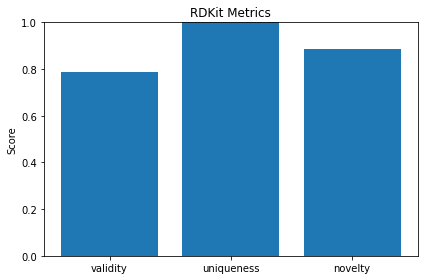

Saved: runs/m1_chem_tok_v1/plot_metrics_bar.png


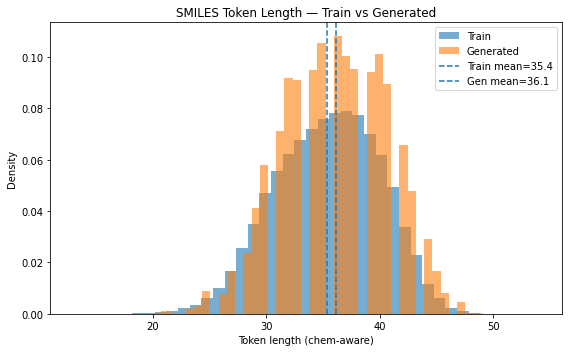

Saved: runs/m1_chem_tok_v1/plot_token_len_hist.png


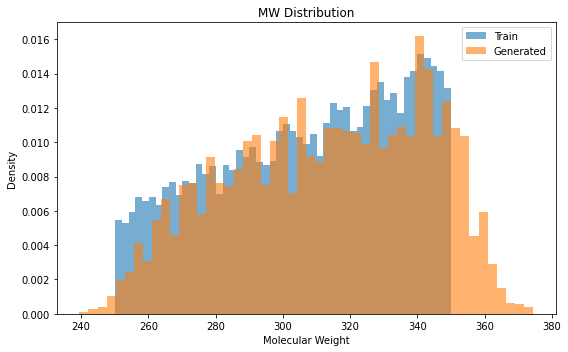

Saved: runs/m1_chem_tok_v1/plot_mw_hist.png


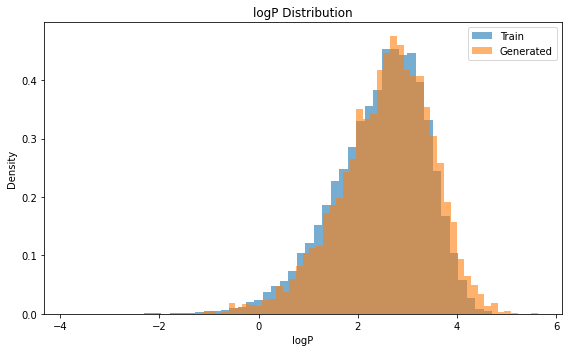

Saved: runs/m1_chem_tok_v1/plot_logp_hist.png


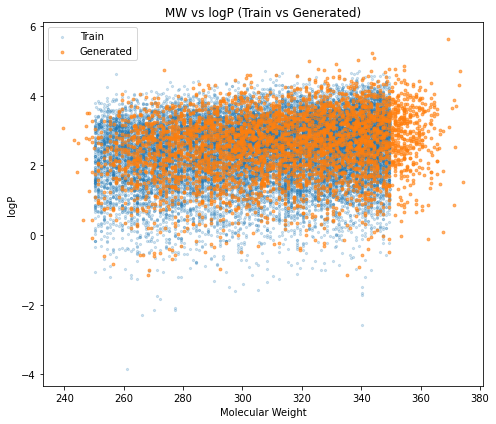

Saved: runs/m1_chem_tok_v1/plot_mw_logp_scatter.png

[done] Plots saved in: runs/m1_chem_tok_v1


In [30]:
# ==== Plot Cell — RDKit+SMILES graphs (validity/uniqueness/novelty, token lengths, MW/logP) ====
import os, json, math, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from rdkit import Chem
from rdkit.Chem import Descriptors
from transformers import GPT2LMHeadModel

# -----------------------------
# 0) Locate RUN_DIR and model_dir
# -----------------------------
if 'RUN_DIR' not in globals():
    # try both common defaults used in this notebook family
    for p in ["runs/birdie_bandit_v1", "runs/m1_chem_tok_v1"]:
        if Path(p).exists():
            RUN_DIR = Path(p)
            break
    else:
        RUN_DIR = Path("runs/birdie_bandit_v1")
RUN_DIR.mkdir(parents=True, exist_ok=True)

model_dir = Path(globals().get('model_dir', RUN_DIR / "model_birdie_bandit"))
print(f"[info] Using RUN_DIR={RUN_DIR}")
print(f"[info] Model dir candidate: {model_dir}")

# -----------------------------
# 1) Minimal chem helpers (robust to restarts)
# -----------------------------
# chem_tokenize fallback (only if not already defined)
if 'chem_tokenize' not in globals():
    BRACKET_RE = re.compile(r"\[[^\[\]]+\]")
    RING2_RE   = re.compile(r"%\d{2}")
    TWO_LETTER = {"Cl","Br"}
    BONDS      = set(list("=#:-/\\."))     # keep '.'
    BRANCHES   = {"(",")"}
    DIGITS     = set(list("0123456789"))
    AROMATICS  = set(list("bcno sp".replace(" ","")))
    ELEMENTS   = set(list("BCNOPFISH"))
    def chem_tokenize(smiles: str):
        out = []; i, L = 0, len(smiles or "")
        while i < L:
            ch = smiles[i]
            if ch == "[":
                m = BRACKET_RE.match(smiles, i)
                if m: out.append(m.group(0)); i = m.end(); continue
            if ch == "%" and i+2 < L and smiles[i+1:i+3].isdigit():
                out.append(smiles[i:i+3]); i += 3; continue
            if i+1 < L and smiles[i:i+2] in TWO_LETTER:
                out.append(smiles[i:i+2]); i += 2; continue
            if ch in BRANCHES or ch in BONDS or ch in DIGITS or ch in AROMATICS or ch in ELEMENTS:
                out.append(ch); i += 1; continue
            out.append(ch); i += 1
        return out

# canonicalizer fallback
if 'canonical_or_none' not in globals():
    def canonical_or_none(s: str):
        try:
            m = Chem.MolFromSmiles(s, sanitize=True)
            if m is None: return None
            return Chem.MolToSmiles(m, isomericSmiles=True, canonical=True)
        except Exception:
            return None

# ChemTokenizer reloader (if ctok missing)
def _load_ctok_from_json(run_dir: Path):
    tok_path = run_dir / "chem_tokenizer.json"
    if not tok_path.exists():
        raise FileNotFoundError(f"chem_tokenizer.json not found at {tok_path}. Run tokenizer cell first.")
    info = json.load(open(tok_path))
    class _CTok:
        def __init__(self, info):
            self.itos = info["itos"]; self.stoi = info["stoi"]
            self.pad_token = info["pad_token"]; self.bos_token = info["bos_token"]; self.eos_token = info["eos_token"]; self.unk_token = info["unk_token"]
            self.pad_token_id = self.stoi[self.pad_token]
            self.bos_token_id = self.stoi[self.bos_token]
            self.eos_token_id = self.stoi[self.eos_token]
            self.unk_token_id = self.stoi[self.unk_token]
            self.vocab_size = len(self.itos)
            self.max_length = max(32, int(info.get("max_length", 128)))
        def encode(self, text: str):
            toks = chem_tokenize(text or "")
            ids_mid = [self.stoi.get(t, self.unk_token_id) for t in toks][: self.max_length - 2]
            ids = [self.bos_token_id] + ids_mid + [self.eos_token_id]
            pad_len = self.max_length - len(ids)
            if pad_len > 0: ids += [self.pad_token_id] * pad_len
            attn = [1] * (len(ids)-max(0,pad_len)) + [0] * max(0,pad_len)
            return {"input_ids": ids, "attention_mask": attn}
        def decode_join(self, ids, skip_special_tokens=True):
            specials = {self.pad_token_id, self.bos_token_id, self.eos_token_id}
            toks = []
            for i in ids:
                if skip_special_tokens and i in specials: continue
                if 0 <= i < self.vocab_size: toks.append(self.itos[i])
            return "".join(toks)
    return _CTok(info)

if 'ctok' not in globals():
    ctok = _load_ctok_from_json(RUN_DIR)
    print("[info] Loaded tokenizer from JSON:", RUN_DIR / "chem_tokenizer.json")

# sampling fallback (explicit attention_mask)
if 'sample_molecules_batched' not in globals():
    @torch.inference_mode()
    def sample_molecules_batched(model, tok, n=1000, batch_size=64, top_p=0.95, temperature=1.0, req_max_len=128):
        model.eval().to("cuda" if torch.cuda.is_available() else "cpu")
        if getattr(model.config, "pad_token_id", None) is None or model.config.pad_token_id == getattr(model.config, "eos_token_id", None):
            model.config.pad_token_id = tok.pad_token_id
        if getattr(model.config, "bos_token_id", None) is None:
            model.config.bos_token_id = tok.bos_token_id
        if getattr(model.config, "eos_token_id", None) is None:
            model.config.eos_token_id = tok.eos_token_id
        mconf = model.config
        bos_id, eos_id, pad_id = mconf.bos_token_id, mconf.eos_token_id, mconf.pad_token_id
        model_max_ctx = int(getattr(mconf, "n_positions", getattr(mconf, "n_ctx", tok.max_length)))
        max_len = min(int(req_max_len), model_max_ctx)
        out = []
        num_batches = math.ceil(n / batch_size)
        for _ in tqdm(range(num_batches), desc="Sampling (plots)"):
            bsz = min(batch_size, n - len(out))
            input_ids = torch.full((bsz, 1), bos_id, device=model.device, dtype=torch.long)
            attention_mask = torch.ones_like(input_ids, dtype=torch.long)
            gen = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_length=max_len,
                do_sample=True, top_p=top_p, temperature=temperature,
                pad_token_id=pad_id, eos_token_id=eos_id
            ).tolist()
            # local decode
            specials = {tok.pad_token_id, tok.bos_token_id, tok.eos_token_id}
            for seq in gen:
                toks = [tok.itos[i] for i in seq if (0 <= i < tok.vocab_size) and (i not in specials)]
                out.append("".join(toks))
        return out[:n]

# -----------------------------
# 2) Get or make: train_df, samples (generated)
# -----------------------------
# train_df (load if missing)
if 'train_df' not in globals():
    clean_path = RUN_DIR / "train_clean.parquet"
    if clean_path.exists():
        train_df = pd.read_parquet(clean_path)
        print(f"[info] Loaded train_df from {clean_path} | n={len(train_df):,}")
    else:
        raise FileNotFoundError(f"train_clean.parquet not found at {clean_path}. Run the data-cleaning cell first.")

# samples: try to reuse 'samples' or 'samples_rs'; else sample from model_dir
samples = globals().get('samples') or globals().get('samples_rs') or None
if samples is None:
    if model_dir.exists():
        print("[info] Sampling fresh molecules for plots...")
        # load model if not in memory
        model_for_plots = globals().get('model_eval') or globals().get('model')
        if model_for_plots is None:
            model_for_plots = GPT2LMHeadModel.from_pretrained(str(model_dir))
        SAMP = globals().get('CONFIG', {}).get('sampling', {"n": 2000, "top_p": 0.95, "temperature": 1.0, "max_length": 128})
        samples = sample_molecules_batched(
            model_for_plots, ctok,
            n=int(SAMP.get("n", 2000)), batch_size=64,
            top_p=float(SAMP.get("top_p", 0.95)),
            temperature=float(SAMP.get("temperature", 1.0)),
            req_max_len=int(SAMP.get("max_length", 128))
        )
    else:
        raise RuntimeError("No generated samples found and no model_dir to sample from. "
                           "Either run sampling earlier or set model_dir.")

# -----------------------------
# 3) Compute metrics & props
# -----------------------------
valid_canon = [c for c in map(canonical_or_none, samples) if c is not None]
validity    = len(valid_canon) / max(1, len(samples))
unique_valid = len(set(valid_canon))
uniqueness  = unique_valid / max(1, len(valid_canon))
train_set_canon = set(train_df["smiles"].tolist())
novel       = sum(1 for s in set(valid_canon) if s not in train_set_canon)
novelty     = novel / max(1, unique_valid)

metrics = {
    "n_samples": len(samples),
    "n_valid": len(valid_canon),
    "validity": round(validity, 4),
    "uniqueness_among_valid": round(uniqueness, 4),
    "novelty_vs_train": round(novelty, 4),
}
print("Metrics:", json.dumps(metrics, indent=2))

def _props(smi):
    m = Chem.MolFromSmiles(smi)
    if m is None: return None
    try:
        return Descriptors.MolWt(m), Descriptors.MolLogP(m)
    except Exception:
        return None

valid_unique = sorted(set(valid_canon))
gen_props = [_props(s) for s in valid_unique]
gen_props = pd.DataFrame([p for p in gen_props if p is not None], columns=["MW","logP"])

train_props = [_props(s) for s in train_df["smiles"].tolist()]
train_props = pd.DataFrame([p for p in train_props if p is not None], columns=["MW","logP"]).sample(
    min(20000, len(train_df)), random_state=0
)

# -----------------------------
# 4) Plots (matplotlib only, one chart per figure)
# -----------------------------
PLOT_DIR = RUN_DIR
# (a) bar: validity/uniqueness/novelty
plt.figure(figsize=(6,4))
bars_x = ["validity","uniqueness","novelty"]
bars_y = [metrics["validity"], metrics["uniqueness_among_valid"], metrics["novelty_vs_train"]]
plt.bar(bars_x, bars_y)
plt.ylim(0,1)
plt.title("RDKit Metrics")
plt.ylabel("Score")
out_a = PLOT_DIR / "plot_metrics_bar.png"; plt.tight_layout(); plt.savefig(out_a, bbox_inches="tight"); plt.show()
print("Saved:", out_a)

# (b) histogram: token length train vs generated
plt.figure(figsize=(8,5))
train_tok_lens = [len(chem_tokenize(s)) for s in train_df["smiles"]]
gen_tok_lens   = [len(chem_tokenize(s)) for s in valid_canon]
plt.hist(train_tok_lens, bins=40, alpha=0.6, label="Train", density=True)
plt.hist(gen_tok_lens, bins=40, alpha=0.6, label="Generated", density=True)
plt.axvline(np.mean(train_tok_lens), linestyle="--", label=f"Train mean={np.mean(train_tok_lens):.1f}")
plt.axvline(np.mean(gen_tok_lens) if gen_tok_lens else 0, linestyle="--", label=f"Gen mean={np.mean(gen_tok_lens):.1f}")
plt.xlabel("Token length (chem-aware)"); plt.ylabel("Density"); plt.title("SMILES Token Length — Train vs Generated")
plt.legend(); plt.tight_layout()
out_b = PLOT_DIR / "plot_token_len_hist.png"; plt.savefig(out_b, bbox_inches="tight"); plt.show()
print("Saved:", out_b)

# (c) histogram: Molecular Weight (train vs generated)
plt.figure(figsize=(8,5))
plt.hist(train_props["MW"], bins=50, alpha=0.6, label="Train", density=True)
if not gen_props.empty:
    plt.hist(gen_props["MW"], bins=50, alpha=0.6, label="Generated", density=True)
plt.xlabel("Molecular Weight"); plt.ylabel("Density"); plt.title("MW Distribution")
plt.legend(); plt.tight_layout()
out_c = PLOT_DIR / "plot_mw_hist.png"; plt.savefig(out_c, bbox_inches="tight"); plt.show()
print("Saved:", out_c)

# (d) histogram: logP (train vs generated)
plt.figure(figsize=(8,5))
plt.hist(train_props["logP"], bins=50, alpha=0.6, label="Train", density=True)
if not gen_props.empty:
    plt.hist(gen_props["logP"], bins=50, alpha=0.6, label="Generated", density=True)
plt.xlabel("logP"); plt.ylabel("Density"); plt.title("logP Distribution")
plt.legend(); plt.tight_layout()
out_d = PLOT_DIR / "plot_logp_hist.png"; plt.savefig(out_d, bbox_inches="tight"); plt.show()
print("Saved:", out_d)

# (e) scatter: MW vs logP (train vs generated)
plt.figure(figsize=(7,6))
plt.scatter(train_props["MW"], train_props["logP"], s=5, alpha=0.2, label="Train")
if not gen_props.empty:
    plt.scatter(gen_props["MW"], gen_props["logP"], s=8, alpha=0.6, label="Generated")
plt.xlabel("Molecular Weight"); plt.ylabel("logP"); plt.title("MW vs logP (Train vs Generated)")
plt.legend(); plt.tight_layout()
out_e = PLOT_DIR / "plot_mw_logp_scatter.png"; plt.savefig(out_e, bbox_inches="tight"); plt.show()
print("Saved:", out_e)

print("\n[done] Plots saved in:", PLOT_DIR)



=== RDKit Metrics ===
Samples       : 5,000
Valid (count) : 3,942
Validity      : 0.7884
Uniqueness    : 0.9997
Novelty       : 0.8843


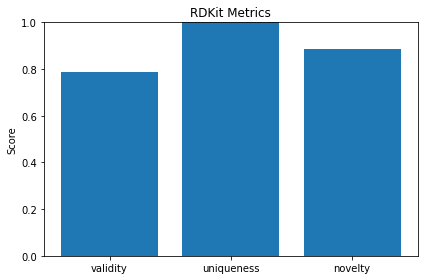

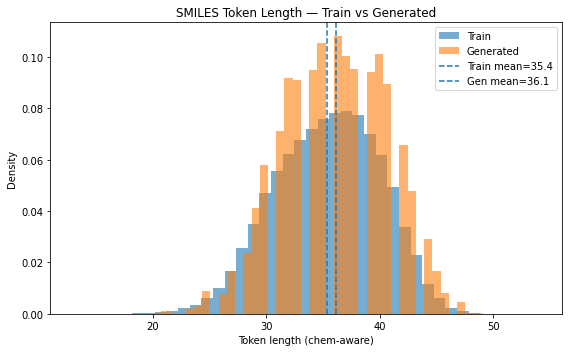

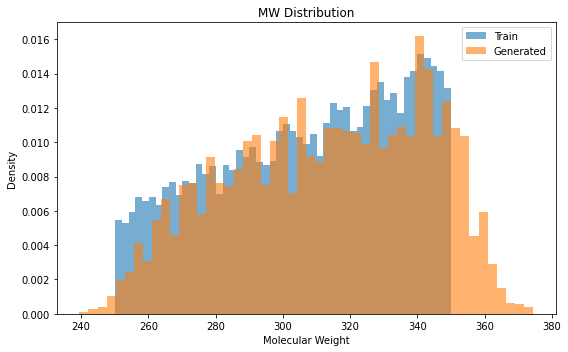

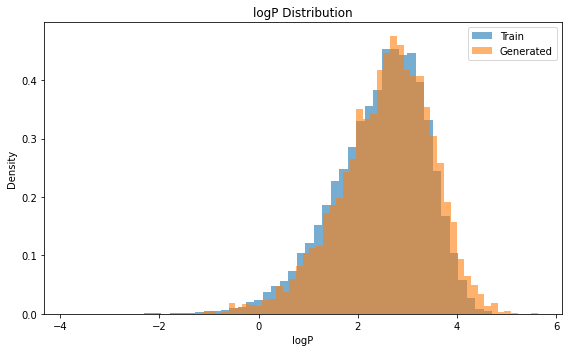

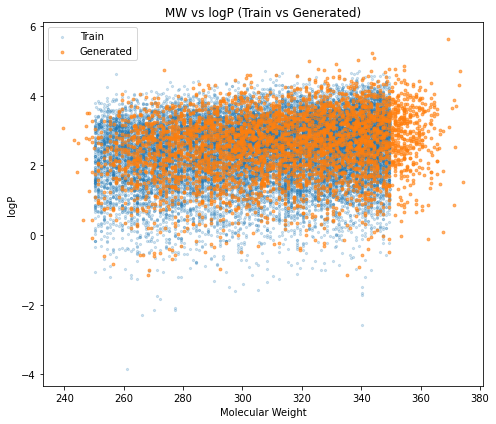

/home/fkrithik/.local/lib/python3.9/site-packages/rdkit/Chem/Draw/IPythonConsole.py:343: UserWarning: Truncating the list of molecules to be displayed to 50. Change the maxMols value to display more.
  warnings.warn(


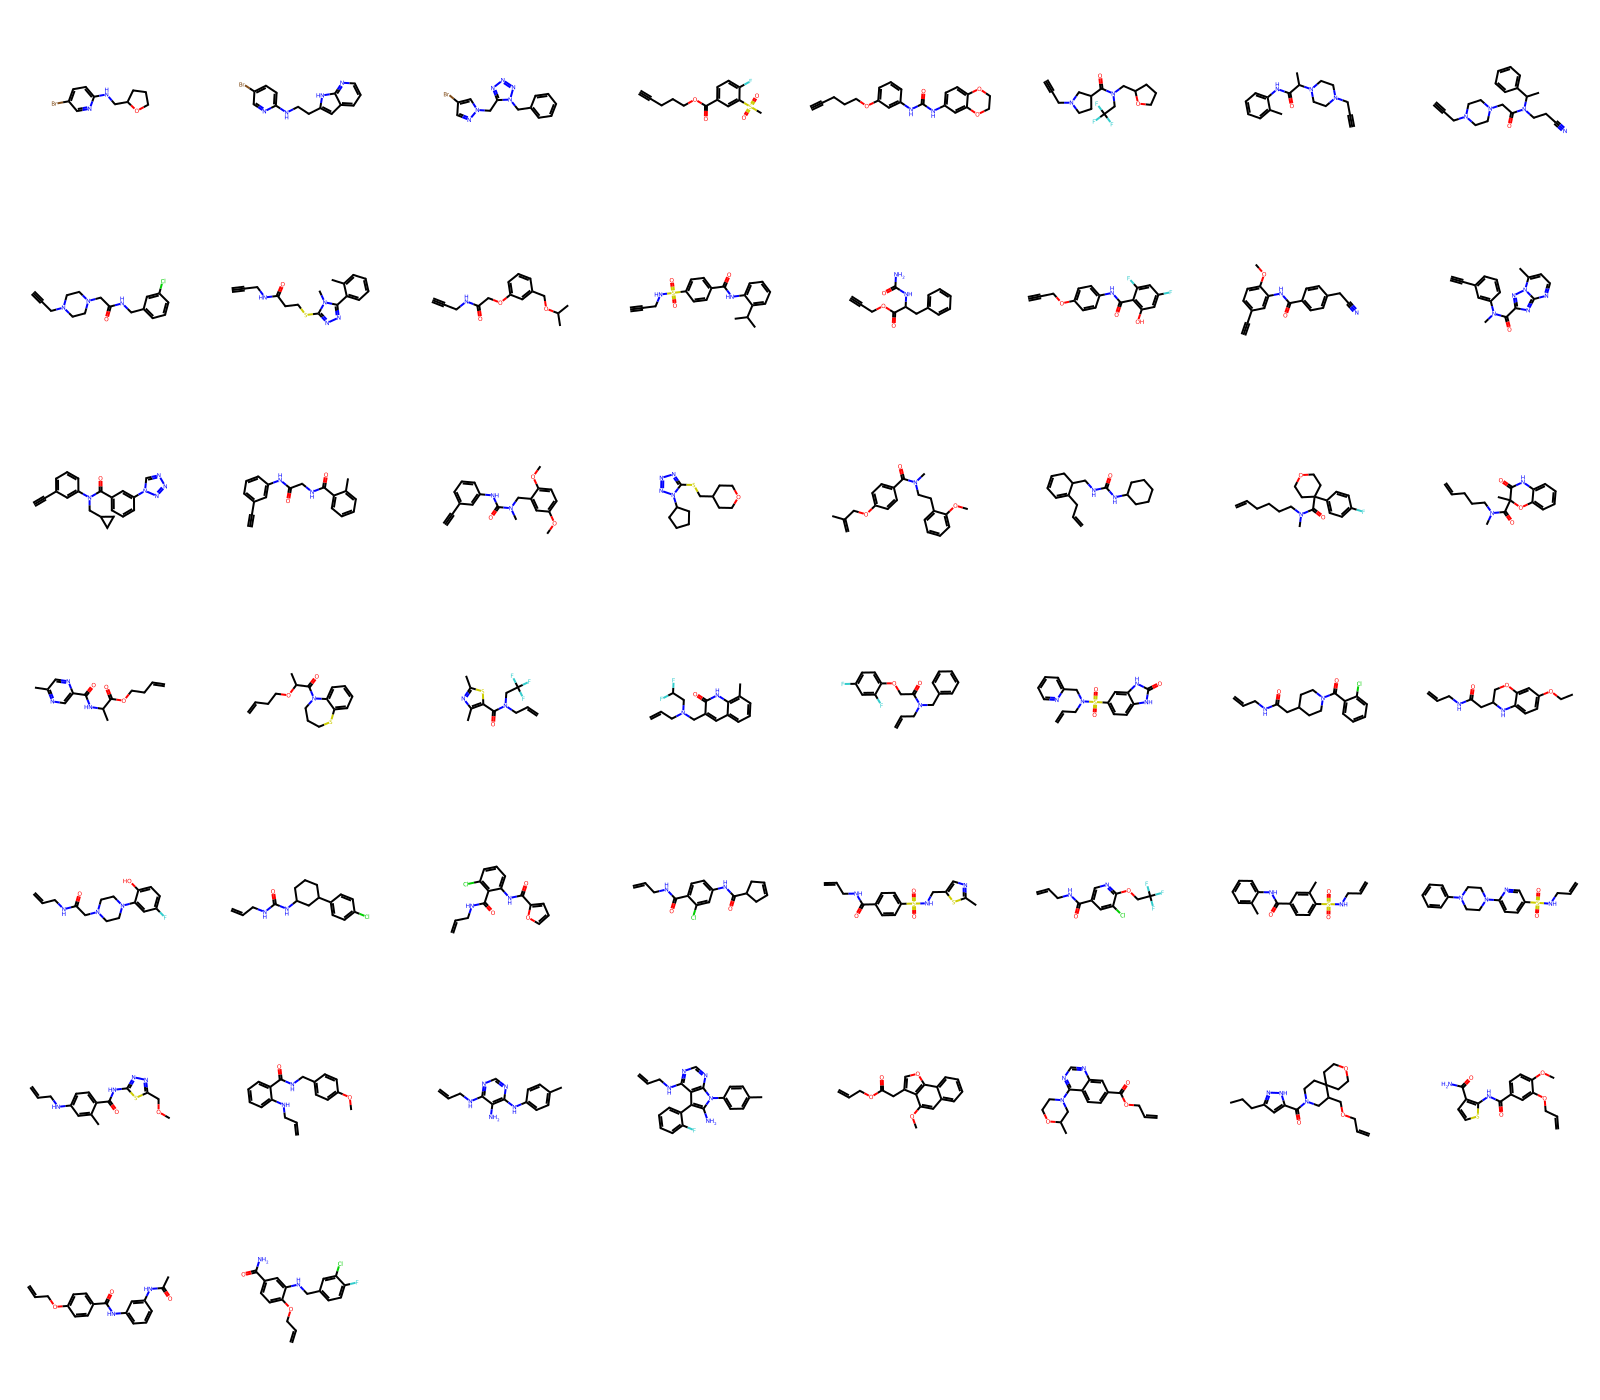

In [31]:
# ==== One-and-done cell: compute metrics AND show all plots inline (no separate saves needed) ====
# It will:
#  - sample (if needed), compute validity/uniqueness/novelty
#  - print a nice metrics table
#  - show: metrics bar, token-length hists, MW/logP hists, MW–logP scatter
#  - (optional) show a small grid of generated molecules if RDKit Draw is available

import os, json, math, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
from rdkit import Chem
from rdkit.Chem import Descriptors
from transformers import GPT2LMHeadModel

# ---------- Locate run dirs and model ----------
if 'RUN_DIR' not in globals():
    for p in ["runs/birdie_bandit_v1", "runs/m1_chem_tok_v1"]:
        if Path(p).exists():
            RUN_DIR = Path(p); break
    else:
        RUN_DIR = Path("runs/birdie_bandit_v1")
RUN_DIR.mkdir(parents=True, exist_ok=True)

model_dir = Path(globals().get('model_dir', RUN_DIR / "model_birdie_bandit"))
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ---------- Minimal chem/token helpers (robust to restarts) ----------
if 'chem_tokenize' not in globals():
    BRACKET_RE = re.compile(r"\[[^\[\]]+\]")
    RING2_RE   = re.compile(r"%\d{2}")
    TWO_LETTER = {"Cl","Br"}
    BONDS      = set(list("=#:-/\\."))     # keep '.'
    BRANCHES   = {"(",")"}
    DIGITS     = set(list("0123456789"))
    AROMATICS  = set(list("bcno sp".replace(" ","")))
    ELEMENTS   = set(list("BCNOPFISH"))
    def chem_tokenize(smiles: str):
        out = []; i, L = 0, len(smiles or "")
        while i < L:
            ch = smiles[i]
            if ch == "[":
                m = BRACKET_RE.match(smiles, i)
                if m: out.append(m.group(0)); i = m.end(); continue
            if ch == "%" and i+2 < L and smiles[i+1:i+3].isdigit():
                out.append(smiles[i:i+3]); i += 3; continue
            if i+1 < L and smiles[i:i+2] in TWO_LETTER:
                out.append(smiles[i:i+2]); i += 2; continue
            if ch in BRANCHES or ch in BONDS or ch in DIGITS or ch in AROMATICS or ch in ELEMENTS:
                out.append(ch); i += 1; continue
            out.append(ch); i += 1
        return out

if 'canonical_or_none' not in globals():
    def canonical_or_none(s: str):
        try:
            m = Chem.MolFromSmiles(s, sanitize=True)
            if m is None: return None
            return Chem.MolToSmiles(m, isomericSmiles=True, canonical=True)
        except Exception:
            return None

# Load tokenizer from disk if needed
def _load_ctok(run_dir: Path):
    info = json.load(open(run_dir / "chem_tokenizer.json"))
    class _CTok:
        def __init__(self, info):
            self.itos = info["itos"]; self.stoi = info["stoi"]
            self.pad_token = info["pad_token"]; self.bos_token = info["bos_token"]; self.eos_token = info["eos_token"]; self.unk_token = info["unk_token"]
            self.pad_token_id = self.stoi[self.pad_token]
            self.bos_token_id = self.stoi[self.bos_token]
            self.eos_token_id = self.stoi[self.eos_token]
            self.unk_token_id = self.stoi[self.unk_token]
            self.vocab_size = len(self.itos)
            self.max_length = max(32, int(info.get("max_length", 128)))
    return _CTok(info)

if 'ctok' not in globals():
    ctok = _load_ctok(RUN_DIR)

# Stable sampler (explicit attention_mask)
if 'sample_molecules_batched' not in globals():
    @torch.inference_mode()
    def sample_molecules_batched(model, tok, n=2000, batch_size=64, top_p=0.95, temperature=1.0, req_max_len=128):
        model.eval().to(DEVICE)
        if getattr(model.config, "pad_token_id", None) is None or model.config.pad_token_id == getattr(model.config, "eos_token_id", None):
            model.config.pad_token_id = tok.pad_token_id
        if getattr(model.config, "bos_token_id", None) is None:
            model.config.bos_token_id = tok.bos_token_id
        if getattr(model.config, "eos_token_id", None) is None:
            model.config.eos_token_id = tok.eos_token_id
        mconf = model.config
        bos_id, eos_id, pad_id = mconf.bos_token_id, mconf.eos_token_id, mconf.pad_token_id
        model_max_ctx = int(getattr(mconf, "n_positions", getattr(mconf, "n_ctx", tok.max_length)))
        max_len = min(int(req_max_len), model_max_ctx)
        out = []
        num_batches = math.ceil(n / batch_size)
        for _ in tqdm(range(num_batches), desc="Sampling (display)"):
            bsz = min(batch_size, n - len(out))
            input_ids = torch.full((bsz, 1), bos_id, device=DEVICE, dtype=torch.long)
            attention_mask = torch.ones_like(input_ids, dtype=torch.long)
            gen = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_length=max_len,
                do_sample=True, top_p=top_p, temperature=temperature,
                pad_token_id=pad_id, eos_token_id=eos_id
            ).tolist()
            specials = {tok.pad_token_id, tok.bos_token_id, tok.eos_token_id}
            for seq in gen:
                toks = [tok.itos[i] for i in seq if (0 <= i < tok.vocab_size) and (i not in specials)]
                out.append("".join(toks))
        return out[:n]

# ---------- Load data & samples ----------
clean_path = RUN_DIR / "train_clean.parquet"
if 'train_df' not in globals():
    if clean_path.exists():
        train_df = pd.read_parquet(clean_path)
    else:
        raise FileNotFoundError(f"{clean_path} not found. Run data-cleaning cell first.")

samples = globals().get('samples') or globals().get('samples_rs')
if samples is None:
    # load model and sample
    if not model_dir.exists():
        raise RuntimeError("No model_dir to sample from. Train or set model_dir.")
    model_for_plots = globals().get('model_eval') or globals().get('model')
    if model_for_plots is None:
        model_for_plots = GPT2LMHeadModel.from_pretrained(str(model_dir)).to(DEVICE)
        # ensure vocab matches tokenizer (in case you added sentinels)
        cur = model_for_plots.get_input_embeddings().num_embeddings
        if cur != ctok.vocab_size:
            model_for_plots.resize_token_embeddings(ctok.vocab_size)
            with torch.no_grad():
                model_for_plots.lm_head.weight = model_for_plots.transformer.wte.weight
    SAMP = globals().get('CONFIG', {}).get('sampling', {"n": 2000, "top_p": 0.95, "temperature": 1.0, "max_length": 128})
    samples = sample_molecules_batched(
        model_for_plots, ctok,
        n=int(SAMP.get("n", 2000)), batch_size=64,
        top_p=float(SAMP.get("top_p", 0.95)),
        temperature=float(SAMP.get("temperature", 1.0)),
        req_max_len=int(SAMP.get("max_length", 128))
    )

# ---------- Metrics ----------
valid_canon = [c for c in map(canonical_or_none, samples) if c is not None]
validity    = len(valid_canon) / max(1, len(samples))
unique_valid = len(set(valid_canon))
uniqueness  = unique_valid / max(1, len(valid_canon))
train_set_canon = set(train_df["smiles"].tolist())
novel       = sum(1 for s in set(valid_canon) if s not in train_set_canon)
novelty     = novel / max(1, unique_valid)

print("\n=== RDKit Metrics ===")
print(f"Samples       : {len(samples):,}")
print(f"Valid (count) : {len(valid_canon):,}")
print(f"Validity      : {validity:.4f}")
print(f"Uniqueness    : {uniqueness:.4f}")
print(f"Novelty       : {novelty:.4f}")

# ---------- Properties ----------
def _props(smi):
    m = Chem.MolFromSmiles(smi)
    if m is None: return None
    try:
        return Descriptors.MolWt(m), Descriptors.MolLogP(m)
    except Exception:
        return None

valid_unique = sorted(set(valid_canon))
gen_props = [_props(s) for s in valid_unique]
gen_props = pd.DataFrame([p for p in gen_props if p is not None], columns=["MW","logP"])
train_props = [_props(s) for s in train_df["smiles"].tolist()]
train_props = pd.DataFrame([p for p in train_props if p is not None], columns=["MW","logP"]).sample(
    min(20000, len(train_df)), random_state=0
)

# ---------- Plots (inline) ----------
# (1) Bar: validity/uniqueness/novelty
plt.figure(figsize=(6,4))
bars_x = ["validity","uniqueness","novelty"]
bars_y = [validity, uniqueness, novelty]
plt.bar(bars_x, bars_y); plt.ylim(0,1)
plt.title("RDKit Metrics"); plt.ylabel("Score"); plt.tight_layout(); plt.show()

# (2) Token-length histogram: Train vs Generated
plt.figure(figsize=(8,5))
train_tok_lens = [len(chem_tokenize(s)) for s in train_df["smiles"]]
gen_tok_lens   = [len(chem_tokenize(s)) for s in valid_canon]
plt.hist(train_tok_lens, bins=40, alpha=0.6, label="Train", density=True)
plt.hist(gen_tok_lens, bins=40, alpha=0.6, label="Generated", density=True)
plt.axvline(np.mean(train_tok_lens), linestyle="--", label=f"Train mean={np.mean(train_tok_lens):.1f}")
if gen_tok_lens:
    plt.axvline(np.mean(gen_tok_lens), linestyle="--", label=f"Gen mean={np.mean(gen_tok_lens):.1f}")
plt.xlabel("Token length (chem-aware)"); plt.ylabel("Density"); plt.title("SMILES Token Length — Train vs Generated")
plt.legend(); plt.tight_layout(); plt.show()

# (3) MW histogram
plt.figure(figsize=(8,5))
plt.hist(train_props["MW"], bins=50, alpha=0.6, label="Train", density=True)
if not gen_props.empty:
    plt.hist(gen_props["MW"], bins=50, alpha=0.6, label="Generated", density=True)
plt.xlabel("Molecular Weight"); plt.ylabel("Density"); plt.title("MW Distribution")
plt.legend(); plt.tight_layout(); plt.show()

# (4) logP histogram
plt.figure(figsize=(8,5))
plt.hist(train_props["logP"], bins=50, alpha=0.6, label="Train", density=True)
if not gen_props.empty:
    plt.hist(gen_props["logP"], bins=50, alpha=0.6, label="Generated", density=True)
plt.xlabel("logP"); plt.ylabel("Density"); plt.title("logP Distribution")
plt.legend(); plt.tight_layout(); plt.show()

# (5) MW vs logP scatter
plt.figure(figsize=(7,6))
plt.scatter(train_props["MW"], train_props["logP"], s=5, alpha=0.2, label="Train")
if not gen_props.empty:
    plt.scatter(gen_props["MW"], gen_props["logP"], s=8, alpha=0.6, label="Generated")
plt.xlabel("Molecular Weight"); plt.ylabel("logP"); plt.title("MW vs logP (Train vs Generated)")
plt.legend(); plt.tight_layout(); plt.show()

# (6) Optional grid of molecules
try:
    from rdkit.Chem import Draw
    grid_samples = valid_unique[:64] if len(valid_unique) >= 64 else valid_unique[:len(valid_unique)]
    mols = [Chem.MolFromSmiles(s) for s in grid_samples]
    mols = [m for m in mols if m is not None]
    if mols:
        img = Draw.MolsToGridImage(mols, molsPerRow=8, subImgSize=(200,200))
        display(img)
except Exception as e:
    print("[warn] RDKit grid draw skipped:", e)
